# AI5707 Assignment 5: Maximum likelihood parameter estimation
Dev Patel, 26120007

In [1]:
import math
import random
import matplotlib.pyplot as plt

random.seed(20)

In [2]:
def merge(left, right):
    merged = []
    i = 0
    j = 0
    while i < len(left) and j < len(right):
        if left[i][0] >= right[j][0]:
            merged.append(left[i])
            i += 1
        else:
            merged.append(right[j])
            j += 1
    merged.extend(left[i:])
    merged.extend(right[j:])
    return merged

def mergeSort(items):
    if len(items) <= 1:
        return items
    middle = len(items) // 2
    left = mergeSort(items[:middle])
    right = mergeSort(items[middle:])
    return merge(left, right)

## Data generation

In [3]:
def gaussianPair():
    while True:
        u = 2 * random.random() - 1
        v = 2 * random.random() - 1
        s = u * u + v * v
        if 0 < s < 1:
            factor = math.sqrt(-2 * math.log(s) / s)
            return u * factor, v * factor

def choleskyLower(cov):
    l11 = math.sqrt(cov[0][0])
    l21 = cov[1][0] / l11
    l22 = math.sqrt(cov[1][1] - l21 * l21)
    return l11, l21, l22

def generateClass(mean, cov, count):
    l11, l21, l22 = choleskyLower(cov)
    points = []
    while len(points) < count:
        z1, z2 = gaussianPair()
        points.append((mean[0] + l11 * z1, mean[1] + l21 * z1 + l22 * z2))
    return points

def shuffleList(items):
    for i in range(len(items) - 1, 0, -1):
        j = int(random.random() * (i + 1))
        items[i], items[j] = items[j], items[i]
    return items

def splitClasses(dataByClass, trainFraction):
    trainByClass = []
    testPoints = []
    testLabels = []
    for label, points in enumerate(dataByClass):
        shuffled = shuffleList(list(points))
        cut = int(trainFraction * len(shuffled))
        trainByClass.append(shuffled[:cut])
        for point in shuffled[cut:]:
            testPoints.append(point)
            testLabels.append(label)
    return trainByClass, testPoints, testLabels

## Maximum likelihood estimation and classification

In [4]:
def sampleMean(points):
    n = len(points)
    return (sum(p[0] for p in points) / n, sum(p[1] for p in points) / n)

def scatterMatrix(points, mean):
    n = len(points)
    a = sum((p[0] - mean[0]) ** 2 for p in points) / n
    b = sum((p[0] - mean[0]) * (p[1] - mean[1]) for p in points) / n
    d = sum((p[1] - mean[1]) ** 2 for p in points) / n
    return [[a, b], [b, d]]

def applyStructure(cov, kind):
    if kind == "spherical":
        v = (cov[0][0] + cov[1][1]) / 2
        return [[v, 0.0], [0.0, v]]
    if kind == "diagonal":
        return [[cov[0][0], 0.0], [0.0, cov[1][1]]]
    return cov

def buildModel(mean, cov, prior):
    det = cov[0][0] * cov[1][1] - cov[0][1] * cov[1][0]
    inv = [[cov[1][1] / det, -cov[0][1] / det], [-cov[1][0] / det, cov[0][0] / det]]
    return {"mean": mean, "cov": cov, "inv": inv, "logDet": math.log(det), "logPrior": math.log(prior)}

def estimateModel(trainByClass, kind, tied):
    total = sum(len(c) for c in trainByClass)
    means = [sampleMean(c) for c in trainByClass]
    scatters = [scatterMatrix(c, m) for c, m in zip(trainByClass, means)]
    if tied:
        pooled = [[0.0, 0.0], [0.0, 0.0]]
        for c, s in zip(trainByClass, scatters):
            weight = len(c) / total
            for i in range(2):
                for j in range(2):
                    pooled[i][j] += weight * s[i][j]
        scatters = [pooled for _ in trainByClass]
    models = []
    for c, m, s in zip(trainByClass, means, scatters):
        models.append(buildModel(m, applyStructure(s, kind), len(c) / total))
    return models

def discriminant(point, model):
    dx = point[0] - model["mean"][0]
    dy = point[1] - model["mean"][1]
    inv = model["inv"]
    dist = dx * (inv[0][0] * dx + inv[0][1] * dy) + dy * (inv[1][0] * dx + inv[1][1] * dy)
    return -0.5 * model["logDet"] - 0.5 * dist + model["logPrior"]

def classify(point, models):
    scores = [discriminant(point, m) for m in models]
    best = 0
    for i in range(1, len(scores)):
        if scores[i] > scores[best]:
            best = i
    return best

def posteriors(point, models):
    scores = [discriminant(point, m) for m in models]
    top = max(scores)
    exps = [math.exp(s - top) for s in scores]
    total = sum(exps)
    return [e / total for e in exps]

## Evaluation: confusion matrix, ROC, plots

In [5]:
def confusionMatrix(trueLabels, predLabels, classCount):
    matrix = [[0] * classCount for _ in range(classCount)]
    for t, p in zip(trueLabels, predLabels):
        matrix[t][p] += 1
    return matrix

def printConfusion(matrix):
    print("True \\ Predicted " + "".join("   Class " + str(j + 1) for j in range(len(matrix))))
    for i, row in enumerate(matrix):
        print("Class " + str(i + 1) + "          " + "".join("{:9d}".format(v) for v in row))

def rocCurve(scores, isPositive):
    pairs = mergeSort(list(zip(scores, isPositive)))
    positives = sum(isPositive)
    negatives = len(pairs) - positives
    tp = 0
    fp = 0
    fprs = [0.0]
    tprs = [0.0]
    for i, (score, flag) in enumerate(pairs):
        if flag:
            tp += 1
        else:
            fp += 1
        if i == len(pairs) - 1 or pairs[i + 1][0] != score:
            fprs.append(fp / negatives)
            tprs.append(tp / positives)
    return fprs, tprs

def areaUnderCurve(fprs, tprs):
    area = 0.0
    for i in range(1, len(fprs)):
        area += (fprs[i] - fprs[i - 1]) * (tprs[i] + tprs[i - 1]) / 2
    return area

classColors = ["tab:red", "tab:green", "tab:blue"]
regionColors = ["#f4b6b6", "#b9e3b9", "#b6c9f0"]

def plotBoundary(ax, models, testPoints, testLabels):
    xs = [p[0] for p in testPoints]
    ys = [p[1] for p in testPoints]
    padX = 0.05 * (max(xs) - min(xs))
    padY = 0.05 * (max(ys) - min(ys))
    xLow, xHigh = min(xs) - padX, max(xs) + padX
    yLow, yHigh = min(ys) - padY, max(ys) + padY
    size = 250
    gridX = [xLow + i * (xHigh - xLow) / (size - 1) for i in range(size)]
    gridY = [yLow + i * (yHigh - yLow) / (size - 1) for i in range(size)]
    regions = [[classify((x, y), models) for x in gridX] for y in gridY]
    ax.contourf(gridX, gridY, regions, levels=[-0.5, 0.5, 1.5, 2.5], colors=regionColors)
    ax.contour(gridX, gridY, regions, levels=[0.5, 1.5], colors="black", linewidths=1)
    for label in range(3):
        px = [p[0] for p, l in zip(testPoints, testLabels) if l == label]
        py = [p[1] for p, l in zip(testPoints, testLabels) if l == label]
        ax.scatter(px, py, s=3, color=classColors[label], alpha=0.6, label="Class " + str(label + 1))
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Decision boundaries with test data")
    ax.legend(markerscale=3)

def plotRoc(ax, models, testPoints, testLabels):
    allPosteriors = [posteriors(p, models) for p in testPoints]
    aucs = []
    for c in range(3):
        scores = [pp[c] for pp in allPosteriors]
        isPositive = [l == c for l in testLabels]
        fprs, tprs = rocCurve(scores, isPositive)
        auc = areaUnderCurve(fprs, tprs)
        aucs.append(auc)
        ax.plot(fprs, tprs, color=classColors[c], label="Class " + str(c + 1) + " vs rest (AUC " + format(auc, ".3f") + ")")
    ax.plot([0, 1], [0, 1], color="gray", linestyle="--")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title("ROC curves (one vs rest)")
    ax.legend(loc="lower right")
    return aucs

def printParameters(models, trueMeans, trueCovs):
    for c, m in enumerate(models):
        print("Class", c + 1)
        if trueMeans is not None:
            print("  mean true     ", [round(v, 3) for v in trueMeans[c]])
        print("  mean estimated", [round(v, 3) for v in m["mean"]])
        if trueCovs is not None:
            print("  cov true      ", [[round(v, 3) for v in row] for row in trueCovs[c]])
        print("  cov estimated ", [[round(v, 3) for v in row] for row in m["cov"]])
        print("  prior estimated", round(math.exp(m["logPrior"]), 4))

results = []

def runExperiment(name, trainByClass, testPoints, testLabels, kind, tied, trueMeans, trueCovs):
    models = estimateModel(trainByClass, kind, tied)
    predictions = [classify(p, models) for p in testPoints]
    matrix = confusionMatrix(testLabels, predictions, 3)
    correct = sum(matrix[i][i] for i in range(3))
    accuracy = correct / len(testPoints)
    print(name)
    print("Training points per class:", [len(c) for c in trainByClass], " test points:", len(testPoints))
    printParameters(models, trueMeans, trueCovs)
    printConfusion(matrix)
    print("Accuracy:", round(accuracy, 4))
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    plotBoundary(axes[0], models, testPoints, testLabels)
    aucs = plotRoc(axes[1], models, testPoints, testLabels)
    fig.suptitle(name)
    plt.tight_layout()
    plt.show()
    results.append({"name": name, "models": models, "matrix": matrix, "accuracy": accuracy, "aucs": aucs,
                    "trueMeans": trueMeans, "trueCovs": trueCovs})

## Question 1: synthetic data, 10000 points per class

Spherical covariance, identical across classes
Training points per class: [8000, 8000, 8000]  test points: 6000
Class 1
  mean true      [0.0, 0.0]
  mean estimated [0.032, 0.009]
  cov true       [[2.0, 0.0], [0.0, 2.0]]
  cov estimated  [[1.99, 0.0], [0.0, 1.99]]
  prior estimated 0.3333
Class 2
  mean true      [3.0, 3.0]
  mean estimated [3.016, 2.979]
  cov true       [[2.0, 0.0], [0.0, 2.0]]
  cov estimated  [[1.99, 0.0], [0.0, 1.99]]
  prior estimated 0.3333
Class 3
  mean true      [6.0, 0.0]
  mean estimated [6.016, -0.002]
  cov true       [[2.0, 0.0], [0.0, 2.0]]
  cov estimated  [[1.99, 0.0], [0.0, 1.99]]
  prior estimated 0.3333
True \ Predicted    Class 1   Class 2   Class 3
Class 1               1852      122       26
Class 2                146     1737      117
Class 3                 18      129     1853
Accuracy: 0.907


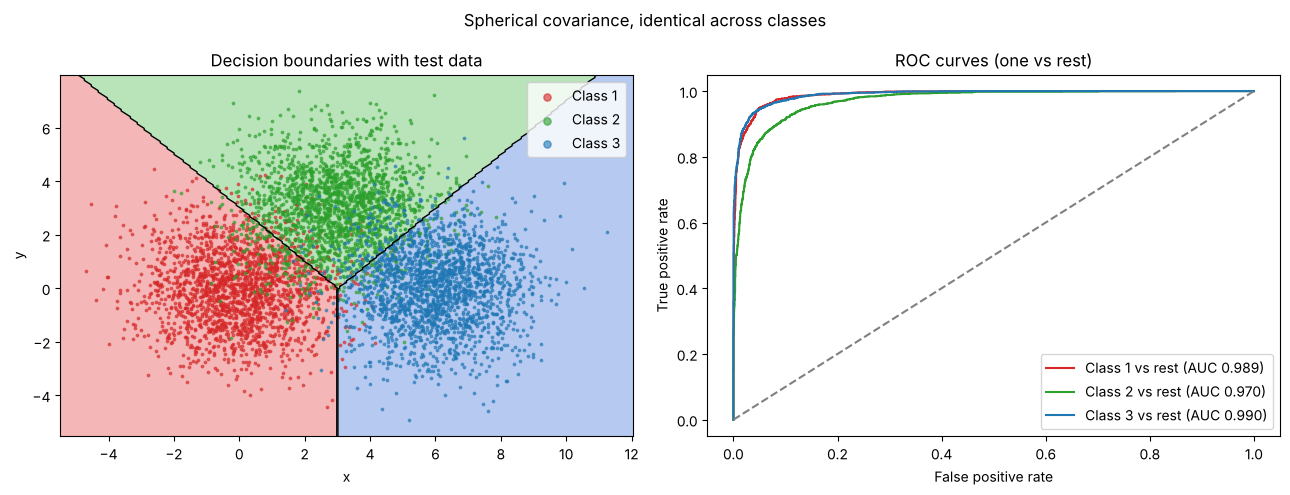

Spherical covariance, different across classes
Training points per class: [8000, 8000, 8000]  test points: 6000
Class 1
  mean true      [0.0, 0.0]
  mean estimated [-0.009, 0.002]
  cov true       [[1.0, 0.0], [0.0, 1.0]]
  cov estimated  [[1.009, 0.0], [0.0, 1.009]]
  prior estimated 0.3333
Class 2
  mean true      [3.0, 3.0]
  mean estimated [2.97, 3.01]
  cov true       [[2.0, 0.0], [0.0, 2.0]]
  cov estimated  [[2.031, 0.0], [0.0, 2.031]]
  prior estimated 0.3333
Class 3
  mean true      [6.0, 0.0]
  mean estimated [6.044, -0.005]
  cov true       [[3.0, 0.0], [0.0, 3.0]]
  cov estimated  [[2.976, 0.0], [0.0, 2.976]]
  prior estimated 0.3333
True \ Predicted    Class 1   Class 2   Class 3
Class 1               1926       60       14
Class 2                 87     1768      145
Class 3                 26      184     1790
Accuracy: 0.914


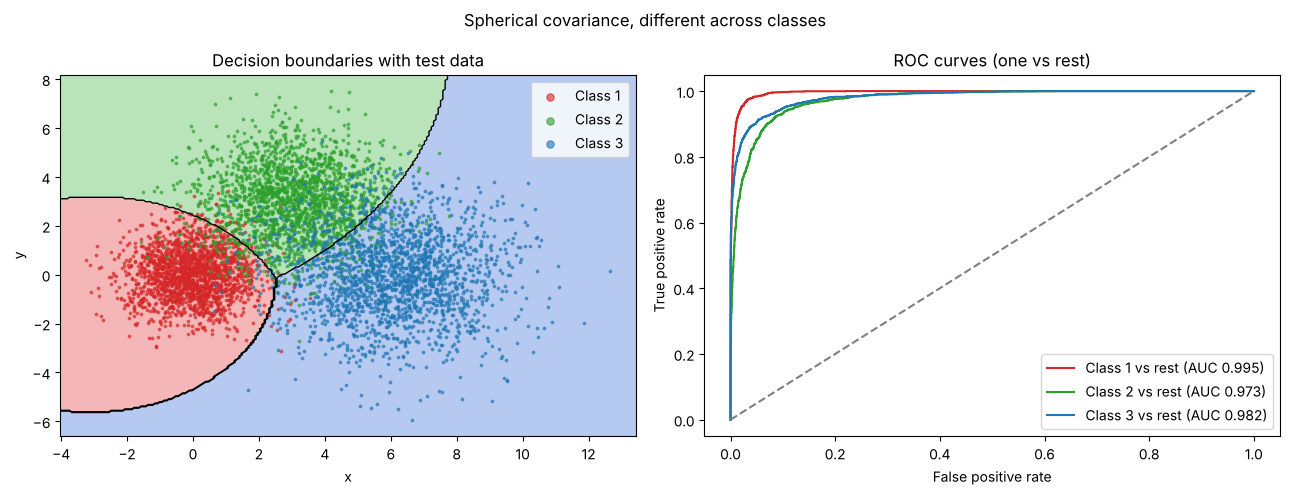

Diagonal covariance, identical across classes
Training points per class: [8000, 8000, 8000]  test points: 6000
Class 1
  mean true      [0.0, 0.0]
  mean estimated [0.015, -0.017]
  cov true       [[3.0, 0.0], [0.0, 1.0]]
  cov estimated  [[3.023, 0.0], [0.0, 0.998]]
  prior estimated 0.3333
Class 2
  mean true      [3.0, 3.0]
  mean estimated [2.982, 2.993]
  cov true       [[3.0, 0.0], [0.0, 1.0]]
  cov estimated  [[3.023, 0.0], [0.0, 0.998]]
  prior estimated 0.3333
Class 3
  mean true      [6.0, 0.0]
  mean estimated [5.998, -0.013]
  cov true       [[3.0, 0.0], [0.0, 1.0]]
  cov estimated  [[3.023, 0.0], [0.0, 0.998]]
  prior estimated 0.3333
True \ Predicted    Class 1   Class 2   Class 3
Class 1               1848       73       79
Class 2                 65     1863       72
Class 3                 74       82     1844
Accuracy: 0.9258


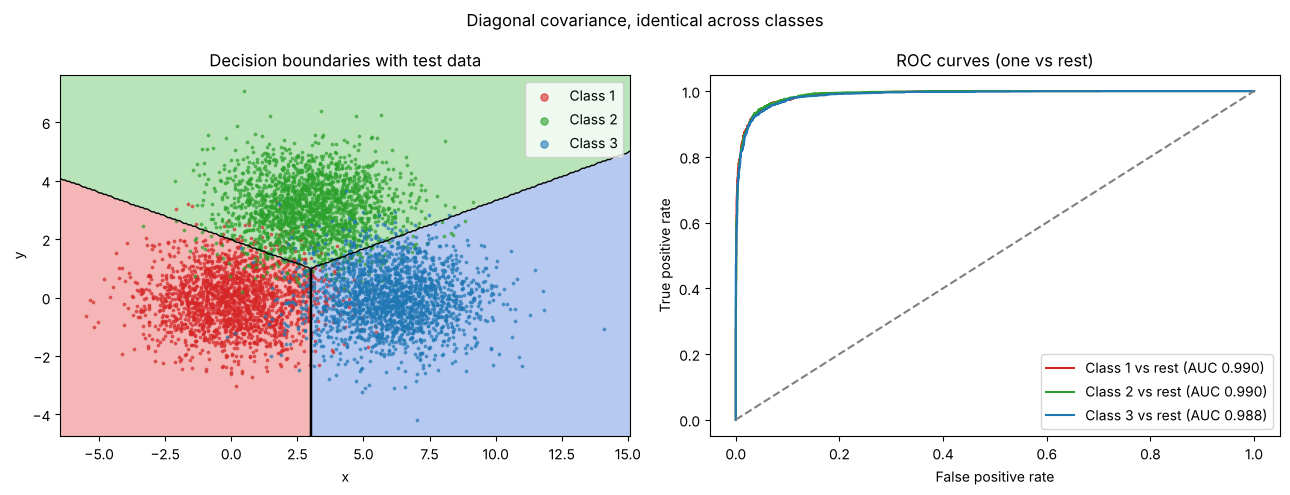

Diagonal covariance, different across classes
Training points per class: [8000, 8000, 8000]  test points: 6000
Class 1
  mean true      [0.0, 0.0]
  mean estimated [-0.005, -0.001]
  cov true       [[1.0, 0.0], [0.0, 3.0]]
  cov estimated  [[0.994, 0.0], [0.0, 2.903]]
  prior estimated 0.3333
Class 2
  mean true      [3.0, 3.0]
  mean estimated [2.993, 2.994]
  cov true       [[3.0, 0.0], [0.0, 1.0]]
  cov estimated  [[3.02, 0.0], [0.0, 0.979]]
  prior estimated 0.3333
Class 3
  mean true      [6.0, 0.0]
  mean estimated [5.995, -0.003]
  cov true       [[0.5, 0.0], [0.0, 2.0]]
  cov estimated  [[0.508, 0.0], [0.0, 2.008]]
  prior estimated 0.3333
True \ Predicted    Class 1   Class 2   Class 3
Class 1               1849      151        0
Class 2                121     1778      101
Class 3                  0       81     1919
Accuracy: 0.9243


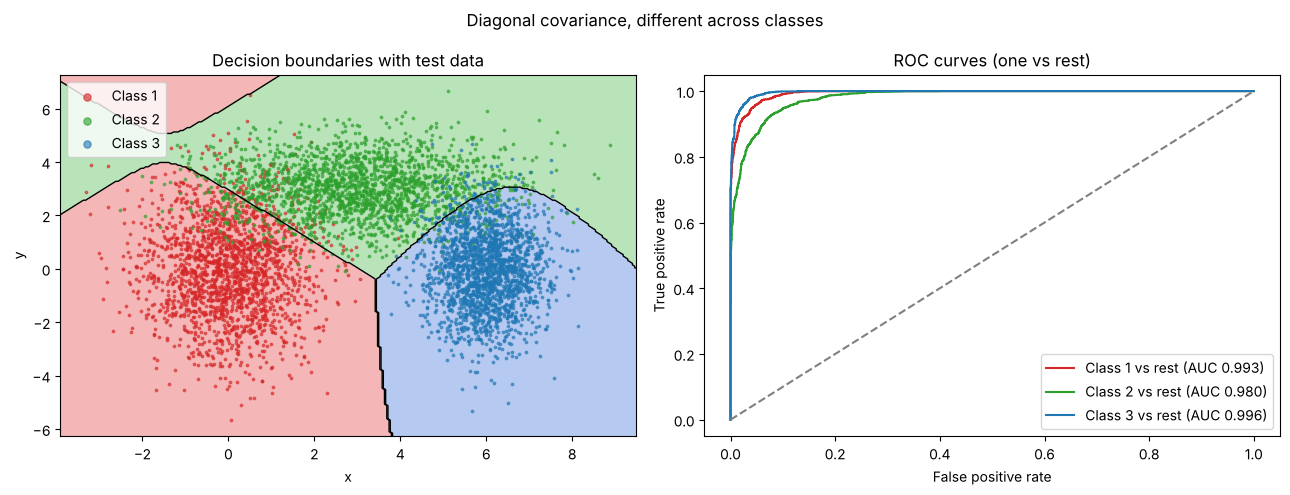

Full covariance, identical across classes
Training points per class: [8000, 8000, 8000]  test points: 6000
Class 1
  mean true      [0.0, 0.0]
  mean estimated [-0.017, -0.002]
  cov true       [[3.0, 1.2], [1.2, 1.5]]
  cov estimated  [[3.016, 1.208], [1.208, 1.506]]
  prior estimated 0.3333
Class 2
  mean true      [3.0, 3.0]
  mean estimated [2.987, 2.993]
  cov true       [[3.0, 1.2], [1.2, 1.5]]
  cov estimated  [[3.016, 1.208], [1.208, 1.506]]
  prior estimated 0.3333
Class 3
  mean true      [6.0, 0.0]
  mean estimated [5.998, -0.01]
  cov true       [[3.0, 1.2], [1.2, 1.5]]
  cov estimated  [[3.016, 1.208], [1.208, 1.506]]
  prior estimated 0.3333
True \ Predicted    Class 1   Class 2   Class 3
Class 1               1743      224       33
Class 2                196     1778       26
Class 3                 21       18     1961
Accuracy: 0.9137


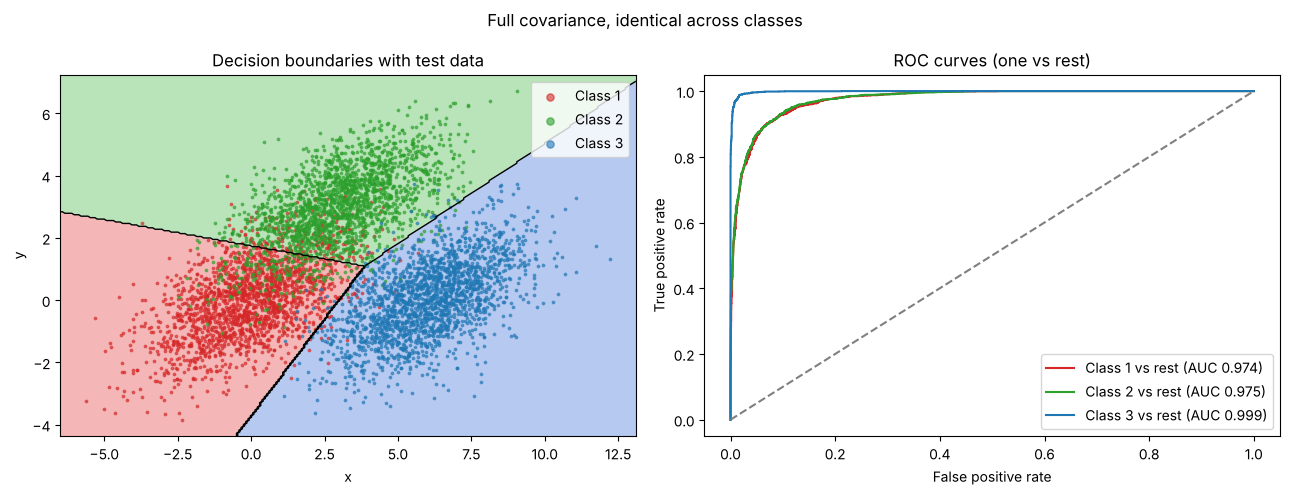

Full covariance, different across classes
Training points per class: [8000, 8000, 8000]  test points: 6000
Class 1
  mean true      [0.0, 0.0]
  mean estimated [0.002, -0.015]
  cov true       [[2.0, 1.0], [1.0, 2.0]]
  cov estimated  [[1.995, 1.008], [1.008, 1.999]]
  prior estimated 0.3333
Class 2
  mean true      [3.0, 3.0]
  mean estimated [3.008, 2.988]
  cov true       [[2.0, -1.2], [-1.2, 2.0]]
  cov estimated  [[2.013, -1.222], [-1.222, 2.043]]
  prior estimated 0.3333
Class 3
  mean true      [6.0, 0.0]
  mean estimated [6.006, -0.005]
  cov true       [[3.0, 0.5], [0.5, 1.0]]
  cov estimated  [[2.979, 0.529], [0.529, 1.005]]
  prior estimated 0.3333
True \ Predicted    Class 1   Class 2   Class 3
Class 1               1841      132       27
Class 2                 50     1799      151
Class 3                 43       87     1870
Accuracy: 0.9183


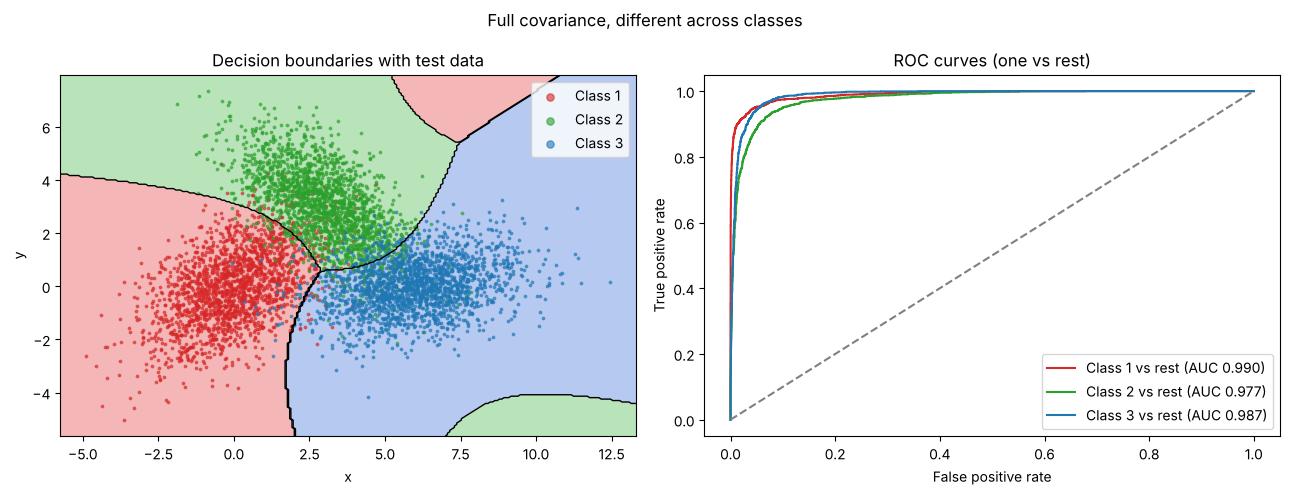

In [6]:
trueMeans = [(0.0, 0.0), (3.0, 3.0), (6.0, 0.0)]

scenarios = [
    ("Spherical covariance, identical across classes", "spherical", True,
     [[[2.0, 0.0], [0.0, 2.0]]] * 3),
    ("Spherical covariance, different across classes", "spherical", False,
     [[[1.0, 0.0], [0.0, 1.0]], [[2.0, 0.0], [0.0, 2.0]], [[3.0, 0.0], [0.0, 3.0]]]),
    ("Diagonal covariance, identical across classes", "diagonal", True,
     [[[3.0, 0.0], [0.0, 1.0]]] * 3),
    ("Diagonal covariance, different across classes", "diagonal", False,
     [[[1.0, 0.0], [0.0, 3.0]], [[3.0, 0.0], [0.0, 1.0]], [[0.5, 0.0], [0.0, 2.0]]]),
    ("Full covariance, identical across classes", "full", True,
     [[[3.0, 1.2], [1.2, 1.5]]] * 3),
    ("Full covariance, different across classes", "full", False,
     [[[2.0, 1.0], [1.0, 2.0]], [[2.0, -1.2], [-1.2, 2.0]], [[3.0, 0.5], [0.5, 1.0]]]),
]

for name, kind, tied, trueCovs in scenarios:
    dataByClass = [generateClass(trueMeans[c], trueCovs[c], 10000) for c in range(3)]
    trainByClass, testPoints, testLabels = splitClasses(dataByClass, 0.8)
    runExperiment(name, trainByClass, testPoints, testLabels, kind, tied, trueMeans, trueCovs)

## Question 2: real 2-D data (team 20)

Training points per class: [350, 350, 350]
Test points per class: [100, 100, 100]
Real data, full covariance different per class
Training points per class: [350, 350, 350]  test points: 300
Class 1
  mean estimated [411.204, 1225.68]
  cov estimated  [[19289.1, 33653.33], [33653.33, 167596.167]]
  prior estimated 0.3333
Class 2
  mean estimated [410.618, 1916.377]
  cov estimated  [[13088.667, -8113.521], [-8113.521, 48760.912]]
  prior estimated 0.3333
Class 3
  mean estimated [585.363, 1419.681]
  cov estimated  [[20804.827, 2500.724], [2500.724, 48398.066]]
  prior estimated 0.3333
True \ Predicted    Class 1   Class 2   Class 3
Class 1                 81        5       14
Class 2                  0       90       10
Class 3                 13       18       69
Accuracy: 0.8


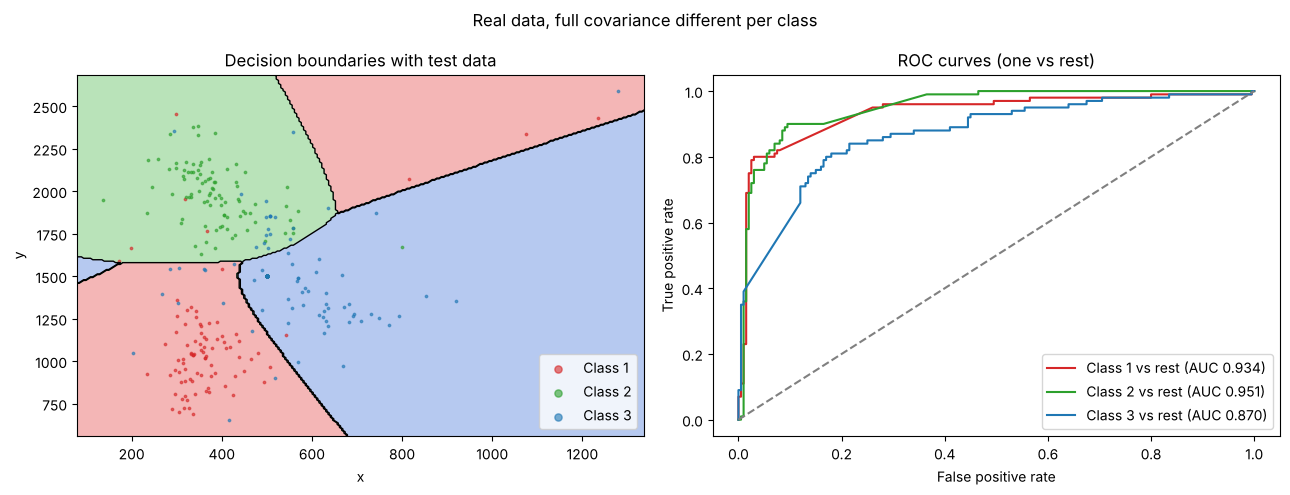

In [7]:
def loadPoints(path):
    byClass = [[], [], []]
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                x, y, label = line.split(",")
                byClass[int(label) - 1].append((float(x), float(y)))
    return byClass

realTrain = loadPoints("20/trian.txt")
realTest = loadPoints("20/dev.txt")
realTestPoints = []
realTestLabels = []
for label, points in enumerate(realTest):
    for point in points:
        realTestPoints.append(point)
        realTestLabels.append(label)

print("Training points per class:", [len(c) for c in realTrain])
print("Test points per class:", [len(c) for c in realTest])

runExperiment("Real data, full covariance different per class", realTrain, realTestPoints, realTestLabels,
              "full", False, None, None)

## Summary

In [8]:
print("{:<52}{:>9}{:>9}{:>9}{:>9}".format("Problem", "Accuracy", "AUC 1", "AUC 2", "AUC 3"))
for r in results:
    print("{:<52}{:>9.4f}{:>9.4f}{:>9.4f}{:>9.4f}".format(r["name"], r["accuracy"], r["aucs"][0], r["aucs"][1], r["aucs"][2]))

Problem                                              Accuracy    AUC 1    AUC 2    AUC 3
Spherical covariance, identical across classes         0.9070   0.9888   0.9703   0.9895
Spherical covariance, different across classes         0.9140   0.9954   0.9731   0.9820
Diagonal covariance, identical across classes          0.9258   0.9896   0.9898   0.9879
Diagonal covariance, different across classes          0.9243   0.9933   0.9803   0.9965
Full covariance, identical across classes              0.9137   0.9742   0.9755   0.9987
Full covariance, different across classes              0.9183   0.9899   0.9766   0.9870
Real data, full covariance different per class         0.8000   0.9343   0.9507   0.8701
